In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned/ipo_cleaned.csv')

print("Shape:", df.shape)
print("\nIssue_Size_Category counts:")
print(df['Issue_Size_Category'].value_counts())

Shape: (549, 19)

Issue_Size_Category counts:
Issue_Size_Category
Small     231
Medium    228
Large      90
Name: count, dtype: int64


C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_25524\144919466.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


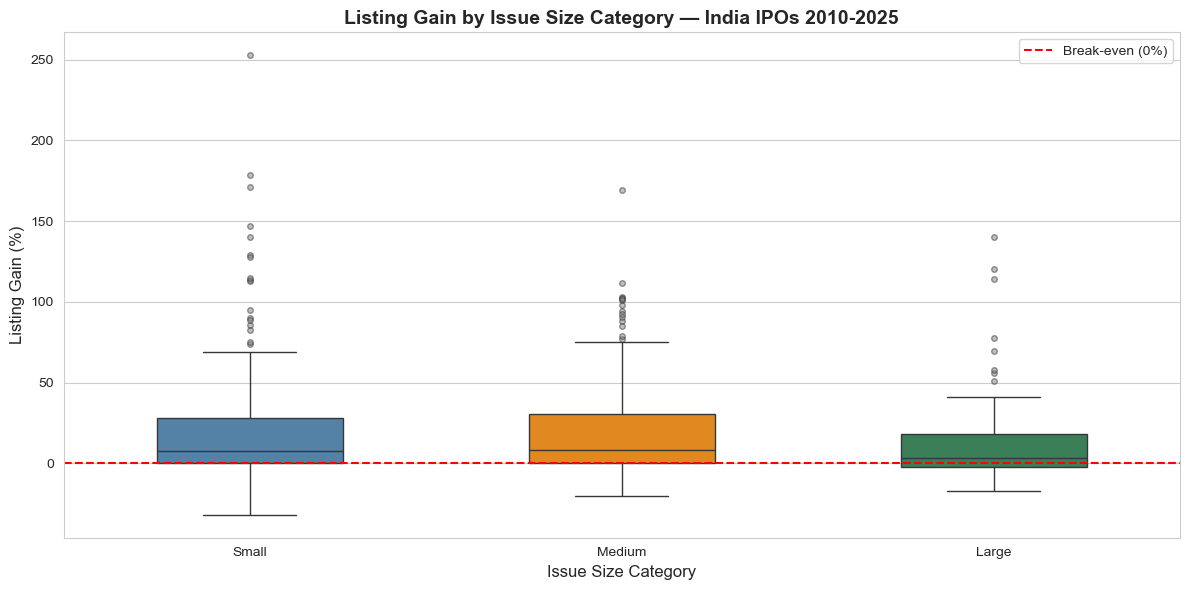

Chart saved.


In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
fig, ax = plt.subplots()

# Define category order — Small to Large left to right
category_order = ['Small', 'Medium', 'Large']

sns.boxplot(
    data=df,
    x='Issue_Size_Category',
    y='Listing Gain',
    order=category_order,
    palette=['steelblue', 'darkorange', 'seagreen'],
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='gray',
                    markersize=4, alpha=0.5),
    ax=ax
)
ax.axhline(y=0, color='red', linestyle='--',
           linewidth=1.5, label='Break-even (0%)')
ax.set_title('Listing Gain by Issue Size Category — India IPOs 2010-2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Issue Size Category', fontsize=12)
ax.set_ylabel('Listing Gain (%)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../charts/07_issue_size_vs_listing_gain.png', dpi=150)
plt.show()
print("Chart saved.")

In [5]:
size_summary = df.groupby('Issue_Size_Category').agg(
    count           = ('IPO_Name', 'count'),
    avg_gain        = ('Listing Gain', 'mean'),
    median_gain     = ('Listing Gain', 'median'),
    pct_profitable  = ('Listing Gain', lambda x: (x > 0).sum() / len(x) * 100),
    avg_qib         = ('QIB', 'mean')
).round(2)

print(size_summary)

                     count  avg_gain  median_gain  pct_profitable  avg_qib
Issue_Size_Category                                                       
Large                   90     12.46         3.32           63.33    34.17
Medium                 228     18.99         8.11           72.81    58.20
Small                  231     19.79         7.56           68.40    44.10
